In [72]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [73]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [74]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [75]:
HF_TOKEN=os.getenv("HF_TOKEN")
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGSMITH_API_KEY=os.getenv("LANGSMITH_API_KEY")

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GROQ_API_KEY"]= GROQ_API_KEY
os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

In [76]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.1-8b-instant")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4763.21it/s]


In [77]:
llm.invoke("hey, I am satyam, how are you doing today?")

AIMessage(content="Hello Satyam, I'm doing well, thanks for asking. I'm a large language model, so I don't have emotions like humans do, but I'm functioning properly and ready to assist you with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 49, 'total_tokens': 114, 'completion_time': 0.070819197, 'completion_tokens_details': None, 'prompt_time': 0.041460026, 'prompt_tokens_details': None, 'queue_time': 0.263044631, 'total_time': 0.112279223}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4423-36a0-79e2-9709-b5bbed42949d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 65, 'total_tokens': 114})

In [78]:
url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [79]:
WebBaseLoader(url).load()


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [80]:
WebBaseLoader(url).load()[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [81]:
WebBaseLoader(url).load()[0].metadata["description"]

'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model 

In [82]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]


In [83]:

docs = [WebBaseLoader(url).load() for url in urls]

In [84]:
docs_list=[item for sublist in docs for item in sublist]

In [85]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=25)


In [86]:

doc_splits=text_splitter.split_documents(docs_list)

In [87]:

doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [88]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chrome",
    embedding=embeddings
    
)

In [89]:

retriever=vectorstore.as_retriever()

In [90]:
# ✅ Clean description only — no behavioral instructions
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.",
)

tools = [retriever_tool]
retrieve = ToolNode([retriever_tool])

In [91]:

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [92]:
from langchain_core.messages import SystemMessage

# ✅ System prompt defined globally, outside the function
system_prompt = SystemMessage(content="""You are a helpful assistant.
Use the 'retrieve_blog_posts' tool ONLY for questions about LLM agents,
prompt engineering, or adversarial attacks on LLMs.
For greetings or general knowledge questions, respond directly without any tool.""")

def ai_assistant(state: AgentState):
    print("---CALL AGENT---")
    
    # ✅ Prepend system prompt to full message history
    messages = [system_prompt] + list(state["messages"])
    
    # ✅ Always bind tools and let LLM decide whether to use them
    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}

In [93]:

class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'yes' or 'no'")

In [94]:
def grade_documents(state: AgentState) -> Literal["generator", "rewriter"]:
    
    llm_with_structure_op = llm.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user's question.
                    Here is the document: {context}
                    Here is the user's question: {question}
                    If the document talks about or contains information related to the user's question, mark it as relevant.
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
        input_variables=["context", "question"]
    )

    chain = prompt | llm_with_structure_op
    messages = state["messages"]

    # ✅ Get latest HumanMessage instead of always messages[0]
    question = next(
        m.content for m in reversed(messages)
        if isinstance(m, HumanMessage)
    )

    last_message = messages[-1]
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewriter"

In [95]:
rag_prompt=hub.pull("rlm/rag-prompt").pretty_print()


================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [123]:
def generate(state: AgentState):
    print("---GENERATE---")
    messages = state["messages"]

    # ✅ Get latest HumanMessage instead of always messages[0]
    question = next(
        m.content for m in reversed(messages)
        if isinstance(m, HumanMessage)
    )

    last_message = messages[-1]
    docs = last_message.content
    rag_prompt=hub.pull("rlm/rag-prompt")

    # ✅ rag_prompt pulled globally, not inside function
    rag_chain = rag_prompt | llm
    response = rag_chain.invoke({"context": docs, "question": question})

    # ✅ Print only .content, not full AIMessage object
    print(f"this is my response: {response.content}")
    
    return {"messages": [response]}

In [124]:
def rewrite(state: AgentState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]

    # ✅ Get latest HumanMessage instead of always messages[0]
    question = next(
        m.content for m in reversed(messages)
        if isinstance(m, HumanMessage)
    )

    message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning.
                Here is the initial question: {question}
                Formulate an improved question: """)]

    response = llm.invoke(message)
    
    return {"messages": [response]}

In [125]:
workflow=StateGraph(AgentState)
workflow.add_node("My_Ai_Assistant",ai_assistant)
workflow.add_node("Vector_Retriever", retrieve) 
workflow.add_node("Output_Generator", generate)
workflow.add_node("Query_Rewriter", rewrite) 

In [126]:
workflow.add_edge(START,"My_Ai_Assistant")

In [127]:
workflow.add_conditional_edges(
    "My_Ai_Assistant",
    tools_condition,
    {
        "tools": "Vector_Retriever",
        END: END,
    }
)

In [128]:

workflow.add_conditional_edges(
    "Vector_Retriever",
    grade_documents,
    {
        "generator": "Output_Generator",
        "rewriter": "Query_Rewriter"
    }
)

In [129]:
workflow.add_edge("Output_Generator", END)

In [130]:
workflow.add_edge("Query_Rewriter", "My_Ai_Assistant")


In [131]:

app=workflow.compile()

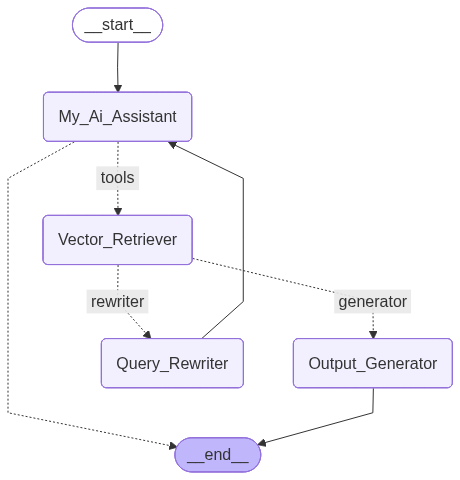

In [132]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [138]:
app.invoke({"messages":["What is a Autonomous Agent?"]})

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response: An Autonomous Agent is a system that uses a Large Language Model (LLM) as its core controller, able to make decisions and solve problems independently. The LLM functions as the agent's "brain," complemented by other key components. This concept is demonstrated through proof-of-concept demos like AutoGPT and BabyAGI.


{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='25536431-5621-4241-a608-4dea64c6e303'),
  AIMessage(content="A autonomous agent is a software system that can perform tasks and make decisions on its own without human intervention. It is a type of artificial intelligence (AI) that can perceive its environment, reason about its actions, and adapt to new situations. Autonomous agents can be found in various forms, such as chatbots, robots, and self-driving cars.\n\nIn the context of deep learning, autonomous agents can be used to control robots or other devices in a physical environment. They can be trained to learn from experience and improve their performance over time.\n\nTo learn more about autonomous agents and their applications, I can look up information from Lilian Weng's blog post on this topic.\n\n", additional_kwargs={'tool_calls': [{'id': 'h2f565wk1', 'function': {'arguments': '{"query":"Autonomous Agents LLMs"}'

In [134]:
app.invoke({"messages":["what is a prompt engineering explain me in terms of agents and langchain?"]})


---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response: I don't have enough information to provide a clear answer about prompt engineering in terms of agents and LangChain. However, it seems that LangChain is a part of the larger concept of building agents using LLMs as core controllers, as seen in demos like AutoGPT, GPT-Engineer, and BabyAGI.


{'messages': [HumanMessage(content='what is a prompt engineering explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='4e216cc2-ce71-4fc3-bc0b-824cad993b9b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'eds55e2yh', 'function': {'arguments': '{"query":"prompt engineering for LLM agents and LangChain"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 328, 'total_tokens': 352, 'completion_time': 0.026419121, 'completion_tokens_details': None, 'prompt_time': 0.023646933, 'prompt_tokens_details': None, 'queue_time': 0.15970415, 'total_time': 0.050066054}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4427-0ef0-7852-a18f-6517a5e1018f-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query'

In [139]:
app.invoke({"messages":["what is capital of india?"]})


---CALL AGENT---


{'messages': [HumanMessage(content='what is capital of india?', additional_kwargs={}, response_metadata={}, id='68d6c640-32da-44e0-a2e2-aeab98173aef'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 319, 'total_tokens': 328, 'completion_time': 0.015325859, 'completion_tokens_details': None, 'prompt_time': 0.070638422, 'prompt_tokens_details': None, 'queue_time': 0.161071276, 'total_time': 0.085964281}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4427-9c71-7782-b580-d15de845c574-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 319, 'output_tokens': 9, 'total_tokens': 328})]}

In [140]:
app.invoke({"messages":["explain about self reflection in agents?"]})

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response: Self-reflection in agents allows them to improve iteratively by refining past action decisions and correcting previous mistakes in real-world tasks. It's created by showing examples of failed trajectories and ideal reflections to the agent, which are then used as context for future decision-making. These reflections are added to the agent's working memory to guide future changes in the plan.


{'messages': [HumanMessage(content='explain about self reflection in agents?', additional_kwargs={}, response_metadata={}, id='b09a36c4-dae7-4a33-9038-941a299bd437'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxjg3qny0', 'function': {'arguments': '{"query":"self reflection in agents"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 320, 'total_tokens': 339, 'completion_time': 0.025669376, 'completion_tokens_details': None, 'prompt_time': 0.025790094, 'prompt_tokens_details': None, 'queue_time': 0.091048064, 'total_time': 0.05145947}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4427-a2ba-7031-b64e-eac60854fe4d-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'self reflection in agents'}, 'id': 'pxjg3qny0', 'typ